# 02 · Pré-processamento

Log-retornos → split temporal → normalização (scaler só no treino) → janelas deslizantes. Lógica em `src/preprocessing.py`; decisões em `docs/adr/0001-split-temporal-antes-do-scaler.md` e `0002`/`0003`.

## Setup

In [1]:
# --- Colab ---
# !git clone https://github.com/Cerne17/NeuraTrade.git
# %cd NeuraTrade
# !pip install -e .

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp

set_seeds()
TICKERS = CONFIG['tickers']
series = data.load_all()
{t: df.shape for t, df in series.items()}

{'PETR4.SA': (3724, 5),
 'VALE3.SA': (3724, 5),
 'AMER3.SA': (3724, 5),
 'ITUB4.SA': (3724, 5)}

## 1. Log-retornos (issue #9)

$r_t = \ln(P_t / P_{t-1})$ sobre o `Close` ajustado. Invariante a escala multiplicativa, logo imune a splits/grupamentos já aplicados.

In [2]:
rets = {t: pp.log_returns(df) for t, df in series.items()}
pd.DataFrame({t: r.describe() for t, r in rets.items()})

,PETR4.SA,VALE3.SA,AMER3.SA,ITUB4.SA
count,3723.000000,3723.000000,3723.000000,3723.000000
mean,0.000372,0.000235,-0.001736,0.000322
std,0.028144,0.025029,0.054954,0.019247
min,-0.352367,-0.281822,-1.484275,-0.198015
25%,-0.013121,-0.012994,-0.022924,-0.010488
50%,0.000429,0.000000,-0.001104,0.000000
75%,0.014133,0.012535,0.019352,0.010810
max,0.200671,0.193573,1.029832,0.111275


## 2. Split temporal ANTES de normalizar (issue #10)

Treino até `train_end` (inclusive), teste estritamente depois. Sem embaralhar.

In [3]:
splits = {t: pp.temporal_split(r) for t, r in rets.items()}
for t, (tr, te) in splits.items():
    print(f'{t}: treino={len(tr)} ({tr.index.min().date()}..{tr.index.max().date()})'
          f'  teste={len(te)} ({te.index.min().date()}..{te.index.max().date()})')

PETR4.SA: treino=2479 (2010-01-05..2019-12-30)  teste=1244 (2020-01-02..2024-12-30)
VALE3.SA: treino=2479 (2010-01-05..2019-12-30)  teste=1244 (2020-01-02..2024-12-30)
AMER3.SA: treino=2479 (2010-01-05..2019-12-30)  teste=1244 (2020-01-02..2024-12-30)
ITUB4.SA: treino=2479 (2010-01-05..2019-12-30)  teste=1244 (2020-01-02..2024-12-30)


## 3. MinMaxScaler ajustado só no treino (issue #11)

`.fit()` no treino, `.transform()` em ambos. **Valores de teste podem sair de [0,1]** — extremos pós-2020 fora do range de treino. Comportamento esperado: é onde moram as anomalias.

In [4]:
for t, (tr, te) in splits.items():
    sc = pp.fit_scaler(tr)
    te_scaled = pp.apply_scaler(sc, te)
    fora = int(((te_scaled < 0) | (te_scaled > 1)).sum())
    print(f'{t}: treino range=[{sc.data_min_[0]:.4f},{sc.data_max_[0]:.4f}]  '
          f'teste fora de [0,1]: {fora} pontos ({100*fora/len(te_scaled):.1f}%)')

PETR4.SA: treino range=[-0.1715,0.1509]  teste fora de [0,1]: 4 pontos (0.3%)
VALE3.SA: treino range=[-0.2818,0.1377]  teste fora de [0,1]: 2 pontos (0.2%)
AMER3.SA: treino range=[-0.1675,0.3479]  teste fora de [0,1]: 15 pontos (1.2%)
ITUB4.SA: treino range=[-0.1284,0.1113]  teste fora de [0,1]: 1 pontos (0.1%)


### Visualização do split e da escala

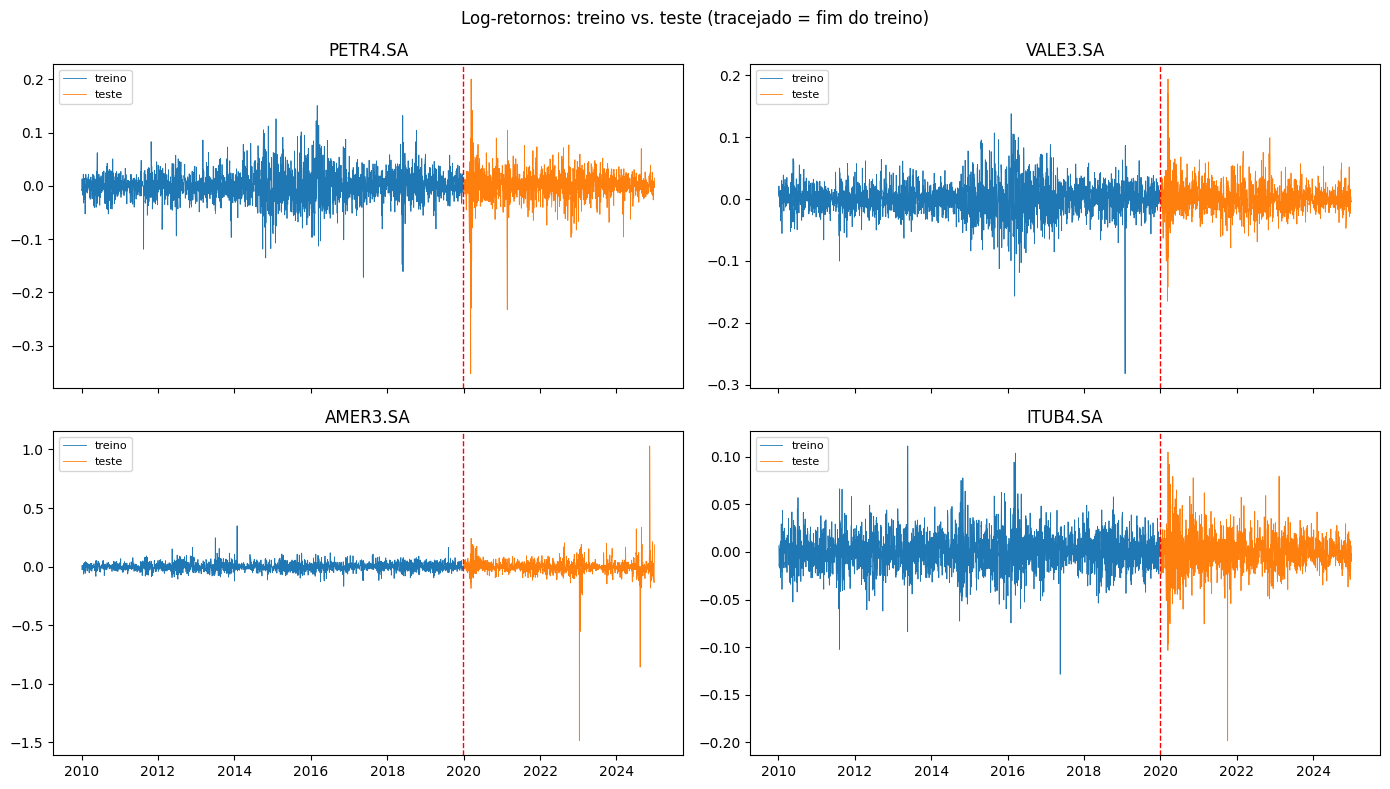

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, t in zip(axes.ravel(), TICKERS):
    tr, te = splits[t]
    ax.plot(tr.index, tr.values, lw=0.6, label='treino')
    ax.plot(te.index, te.values, lw=0.6, label='teste')
    ax.axvline(tr.index.max(), color='red', ls='--', lw=1)
    ax.set_title(t); ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Log-retornos: treino vs. teste (tracejado = fim do treino)')
fig.tight_layout(); plt.show()

## 4. Janelas deslizantes (issue #12)

Tensor `(n, window_size, 1)`, geradas **dentro** de cada partição (nunca cruzam o split). `window_size=30` (ADR-0002). A validação de `window_size` por estabilidade da loss ocorre no treino (M3).

In [6]:
pre = {t: pp.preprocess_ticker(df) for t, df in series.items()}
resumo = pd.DataFrame({
    t: {'X_train': out['X_train'].shape, 'X_test': out['X_test'].shape}
    for t, out in pre.items()
}).T
resumo

,X_train,X_test
PETR4.SA,"(2450, 30, 1)","(1215, 30, 1)"
VALE3.SA,"(2450, 30, 1)","(1215, 30, 1)"
AMER3.SA,"(2450, 30, 1)","(1215, 30, 1)"
ITUB4.SA,"(2450, 30, 1)","(1215, 30, 1)"


In [7]:
# Sanidade: janela = sequencia contigua de retornos normalizados
t0 = TICKERS[0]
X = pre[t0]['X_train']
print(f'{t0}: {X.shape[0]} janelas de {X.shape[1]} passos, {X.shape[2]} feature')
print('primeira janela (10 primeiros valores):', X[0, :10, 0].round(3))

PETR4.SA: 2450 janelas de 30 passos, 1 feature
primeira janela (10 primeiros valores): [0.505 0.574 0.503 0.515 0.522 0.492 0.527 0.478 0.539 0.601]


## Conclusões

- Feature pronta: log-retornos normalizados em janelas de 30 passos, ~2450 janelas de treino e ~1215 de teste por ativo.
- Split temporal e scaler-só-no-treino garantem ausência de vazamento (ADR-0001).
- Pontos de teste fora de [0,1] são esperados e úteis à detecção.
- AMER3 segue o mesmo pipeline, sem tratamento especial (ADR-0007, atualização M2): os saltos de 2024 são anomalias reais, não artefatos de grupamento.
- Próximo (M3): treinar o LSTM-Autoencoder e validar `window_size`/`latent_dim`.